<a href="https://colab.research.google.com/github/Angappan95/langchain-practice/blob/main/04_ToolIntegration_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain langgraph python-dotenv notebook langchain-google-genai

In [ ]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')

In [ ]:
from langchain.chat_models import init_chat_model

try:
  llm = init_chat_model("google_genai:gemini-2.5-flash", google_api_key=GOOGLE_API_KEY)
except Exception as e:
  print(f"Unable to load Gemini model {e}")

In [ ]:
from typing import TypedDict
from langgraph.graph.message import Annotated, add_messages

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [ ]:
def chatbot(state: State):
  return {"messages": [llm.invoke(state['messages'], tools=tools)]}

In [ ]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def get_stock_price(symbol:str):
    """
    Return the current stock price for the given ticker
    """
    stocks_price =  {
        "INFY": "100",
        "TCS": "102",
        "BEL": "98"
    }
    return stocks_price.get(symbol, "NA")
tools = [get_stock_price]

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph.state import START, END

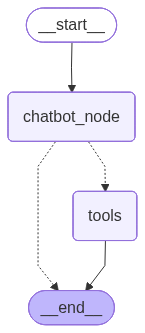

In [ ]:
builder = StateGraph(State)

builder.add_node('chatbot_node', chatbot)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'chatbot_node')
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge('chatbot_node', END)

graph = builder.compile()
graph

In [ ]:
message = "Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock"
response = graph.invoke({"messages": [message]})

In [ ]:
print(response)
print(response['messages'][-1].content) #Unable to calculate the total. it simply returns the stock price as the tool result is not sent to llm for further processing

{'messages': [HumanMessage(content='What is current stock price of TCS', additional_kwargs={}, response_metadata={}, id='2bed0b47-8f00-40d8-8588-710e4767c8d1'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "TCS"}'}, '__gemini_function_call_thought_signatures__': {'9b6998ca-6756-4e07-b456-400160a209b0': 'CqcDAQw51sdQxixXK4vebDc7nJL281DlyzoMaPNb8jeshJDU7ne7cj+IqB6gfKnZ07FzEomiOf5qXnpMVyN+EOVz1TiOuPENKDaxLC0ALSOyqLFw6olKy9jmk2G5IgxRutCuME1pCIEggB0lYpoT+wcZZEShhtGOn2AElpDGR/nV9nt+3wDvLKycVBXIQFjg6Cpci2//1CVTzG6J91NDrL9SjeHclq39UEzbaUDWtBgR6FZD3+tcsFWYU8N7wPqPRH+IjERptlqvWlXwnZtNE8B8Ky12Cepuv5IPsUkJ6a6GRUyNCc67qZPXmSINjzwTxD0zQsPcmo88M7PpGXA+oqCbafdYNZX9pfp1iNtEUKOWcH8DAJulJLCuoYDufT6XtJtftGF5rN9ZfhcyX69SzPfY6YnKWLR3rPqq0YA5ElMT0c6kmHkeQE4PG4cXAssAeDEMqk3cznEJScBSWq7AzAK+/3lSZ/xzDuLOlvD/UMFhEnQgqJjDJ2gPbf5dUdadHXuDum0oa57Xzi1kjmaXZMdfuQsRwS8hy+aX3KNmoyWDG5D/l6UdC9KZ'}}, response_metadata={'finish_reason': 'STOP', 'model_name'

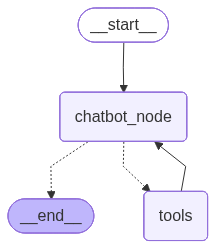

In [ ]:
builder = StateGraph(State)

builder.add_node('chatbot_node', chatbot)
builder.add_node('tools', ToolNode(tools))

builder.add_edge(START, 'chatbot_node')
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge('tools', 'chatbot_node')
builder.add_edge('chatbot_node', END)

graph = builder.compile()
graph

In [ ]:
# Now the tool results are sent back to llm and LLM comprehends the results
message = "Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock"
response = graph.invoke({"messages": [message]})
print(response)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock', additional_kwargs={}, response_metadata={}, id='b624c3ff-1d86-4f45-9b7e-7186e960f507'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "TCS"}'}, '__gemini_function_call_thought_signatures__': {'94c7c451-ec2f-49b2-8d23-dadcdd9874c2': 'CpoEAQw51sf4a4zzES8s9OAOG1MtSHs673AvxPBcXgCRbYfIfbyemB4Z41SBSKRNp2o8VHPs+W2uN33VjpG9DcnoRKp73ygufKV2tTLKkYyiL+VWUhpHS85IgZ0CXJ6XdYOProxuR4klZeoHKlO7x5o4V09LdXsEAg5Itjfkm4nRmf7k2SqrMTo/cY4fjq71+y7qwkz7DAZh+XtXpDMsC+OU0+AolEnm/vAw5f4xbyLmHeqxFckt4Nc943H5YMfc8yHrzHNtzeGlBYezfz1Aw60E4ZDIUgLvHCy3Gp9+MgXrsuRNvAHcr63YTXqltylCejnoV21s81LNZa5tI+Q4WSaSZaleWz4ZchhijAQFnw6ZAo+ttDMiWSxPiafzJeeTDz9vxUlgvRy2D+71d7KrIqdRJzCeSUn6GRNHvGCon0gy8LijjvGz66Zh+uDzBLLJY+SoAaZ3+rPEVXbH+CUiW+FrtV9Exo/kLLBQQf6Aatl8g81FZ9K72foMKER+0iGke2+Pf/GOa1bGBJgZI4vlVQIfiQiFX9BKcDO5kUCGFX5YlPx9t9Zjv/RXWuxAa+4g8r18qKUlWXxw

In [ ]:
import json

messages_as_dicts = [msg.dict() for msg in response['messages']]
print(json.dumps(messages_as_dicts, indent=2))

[
  {
    "content": "Calculate the total price of 10 qtys of TCS stock and 15 qtys of INFY stock",
    "additional_kwargs": {},
    "response_metadata": {},
    "type": "human",
    "name": null,
    "id": "b624c3ff-1d86-4f45-9b7e-7186e960f507"
  },
  {
    "content": "",
    "additional_kwargs": {
      "function_call": {
        "name": "get_stock_price",
        "arguments": "{\"symbol\": \"TCS\"}"
      },
      "__gemini_function_call_thought_signatures__": {
        "94c7c451-ec2f-49b2-8d23-dadcdd9874c2": "CpoEAQw51sf4a4zzES8s9OAOG1MtSHs673AvxPBcXgCRbYfIfbyemB4Z41SBSKRNp2o8VHPs+W2uN33VjpG9DcnoRKp73ygufKV2tTLKkYyiL+VWUhpHS85IgZ0CXJ6XdYOProxuR4klZeoHKlO7x5o4V09LdXsEAg5Itjfkm4nRmf7k2SqrMTo/cY4fjq71+y7qwkz7DAZh+XtXpDMsC+OU0+AolEnm/vAw5f4xbyLmHeqxFckt4Nc943H5YMfc8yHrzHNtzeGlBYezfz1Aw60E4ZDIUgLvHCy3Gp9+MgXrsuRNvAHcr63YTXqltylCejnoV21s81LNZa5tI+Q4WSaSZaleWz4ZchhijAQFnw6ZAo+ttDMiWSxPiafzJeeTDz9vxUlgvRy2D+71d7KrIqdRJzCeSUn6GRNHvGCon0gy8LijjvGz66Zh+uDzBLLJY+SoAaZ3+rPEVXbH+CUiW+FrtV9Exo/kL

/tmp/ipykernel_17007/3054708956.py:3: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  messages_as_dicts = [msg.dict() for msg in response['messages']]
